# Inspecting LISST-Horizon Data from Tara Microbiome

### Import everything needed

In [2]:
! pip install uncertainties

  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
Using cached uncertainties-3.2.3-py3-none-any.whl (60 kB)


In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import glob
import scipy.io
import seaborn as sns
import cartopy.crs as crs


from uncertainties import ufloat
from uncertainties import unumpy

import hrzn_utils

In [4]:
plt.rcParams.update({'font.size': 18})

In [5]:
angles_ssd, angles_fwd, widths_ssd, pathlength_ssd = hrzn_utils.load_in_hrzn_parameters()

In [84]:
angles_fwd

array([ 0.0397769 ,  0.04693674,  0.05538535,  0.06535471,  0.07711855,
        0.09099988,  0.10737984,  0.12670819,  0.14951563,  0.17642838,
        0.20818539,  0.2456586 ,  0.28987687,  0.34205426,  0.40362329,
        0.47627428,  0.56200167,  0.66315872,  0.78252195,  0.92336712,
        1.08955877,  1.28565563,  1.51703468,  1.7900369 ,  2.11213831,
        2.49215024,  2.94045298,  3.46926707,  4.09296639,  4.82843562,
        5.69547228,  6.71722826,  7.9206755 ,  9.33706203, 11.00229052,
       12.95708814])

In [35]:
import importlib
importlib.reload(hrzn_utils)

directory = 'data/LISSTHorizonTara/'
# this is the highly filtered milliQ blank
specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv']
# maybe this is the filtered seawater? need to go and check my notes
# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_17_23.csv']

# directory = 'data/Calibrations 3/'

###

# directory = 'data/TestData_20190117_NASA_Unit/0_5um/'
# specific_zscat_file = ['data/TestData_20190117_NASA_Unit/0_5um/preZscat.csv']


pattern = '*.csv'
csv_files = glob.glob(directory + pattern)

In [42]:
transmission_factor = 1
nnf_factor = 0.15
processed, monte_carlo_results_0, monte_carlo_results_90, cscatFwd_monte_carlo = hrzn_utils.full_process(csv_files[-250:-80], using_fscat=True, 
    apply_atten_corr=True, subtract_zscat=True, empirical_corr_factor=True, transmission_factor=transmission_factor, nnf_factor=nnf_factor)

processed['utc_dt'] = processed.datetime
processed = processed.set_index('utc_dt')
processed = processed.sort_index(ascending=True)
# horizon_df = horizon_df.iloc[1:]

we have: 193864 measurements to process
** Data rows removed due to light-dark error **
   169 row(s) removed
** Data rows removed due to saturation **
   scatSsdRawLight, 2965 row(s) removed
   scatSsdRawDark, 125 row(s) removed


### Set up instrument parameters and ingest matlab files

In [17]:
# the wavelengths we'll interpolate TO
base_wl_ap = ['ap408.5', 'ap411.9', 'ap415.3', 'ap419.2','ap423.5', 'ap427.6', 'ap431.5', 'ap435.7', 'ap439.3', 'ap443.5','ap447.9', 'ap452.7', 'ap457.1', 'ap461', 'ap465.4', 'ap469.8','ap474.3', 'ap479', 'ap483.8', 'ap488.1', 'ap492.3', 'ap496.5','ap500.8', 'ap505.4', 'ap509.9', 'ap514.7', 'ap519', 'ap523.7', 'ap528','ap532', 'ap536.1', 'ap540.4', 'ap544.5', 'ap549.2', 'ap553.3','ap557.5', 'ap561.6', 'ap565.9', 'ap570', 'ap573.7', 'ap577.5','ap582.5', 'ap586.6', 'ap590.7', 'ap594.9', 'ap599.3', 'ap603.6','ap608', 'ap612.3', 'ap616.9', 'ap621.2', 'ap625.5', 'ap629.7','ap633.9', 'ap638.2', 'ap642.3', 'ap646.6', 'ap650.9', 'ap655.5','ap659.8', 'ap664.1', 'ap668.5', 'ap672.6', 'ap676.8', 'ap680.9','ap685', 'ap689', 'ap692.9', 'ap696.6', 'ap700.5', 'ap704.2', 'ap707.9','ap712', 'ap715.5', 'ap719.3', 'ap723', 'ap726.7', 'ap730']

ap_wl = [float(i[2:]) for i in base_wl_ap]

base_wl_ap_sd = ['ap'+str(i)+'_sd' for i in ap_wl]

base_wl_cp = ['cp'+str(i) for i in ap_wl]
base_wl_cp_sd = ['cp'+str(i)+'_sd' for i in ap_wl]

# merge it with all the other data

In [44]:
tara_gdf = gpd.read_feather('../cdom_interp_tara/data/microbiome/TaraMicrobiome_fCDOM_interpolation_ZaneveldRottgers_blended_scattering_correction.feather')

In [45]:
processed['samp_id_group']=processed.sample_id
all_samps = processed[processed.sampleType==0].groupby('samp_id_group').mean()

all_samps['utc_dt'] = all_samps.datetime
all_samps = all_samps.set_index('utc_dt')
all_samps = all_samps.sort_index(ascending=True)

In [47]:
count = 0

fwdvsf_list = []
s11_list = []
s11_0_list = []
dolp_list = []
dolp_0_list = []
beamc_list = []
valid_mask = []

for idx, sid in enumerate(processed.sample_id.unique()):
    samp_df = processed[processed.sample_id == sid]

    pol0 = np.array(monte_carlo_results_0[count])
    pol90 = np.array(monte_carlo_results_90[count])
    beamc_median = np.median(samp_df[samp_df.polarizationAngle==0].beamc)
    vsf_fwd = np.array(cscatFwd_monte_carlo[count*2]).reshape(-1,36).T

    pol0 = np.array(monte_carlo_results_0[count])
    pol90 = np.array(monte_carlo_results_90[count])
    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    
    med90 = np.nanmedian(pol90,axis=(0,1))
    std90 = np.nanstd(pol90,axis=(0,1))

    med90[med90 < 0.00001] = np.nan
    med0[med0 < 0.00001] = np.nan

    s11_full = unumpy.uarray(med0, std0) + unumpy.uarray(med90, std90)
    s12_full = unumpy.uarray(med0, std0) - unumpy.uarray(med90, std90)

    ratio = unumpy.uarray(med90, std90)/unumpy.uarray(med0, std0)
    dolp = -1*((ratio-1) / (ratio+1))

    min90 = np.nanmin(pol90,axis=(0,1))
    max90 = np.nanmax(pol90,axis=(0,1))
    min0  = np.nanmin(pol0,axis=(0,1))
    max0  = np.nanmax(pol0,axis=(0,1))

    min90[min90 < 0] =0
    min0[min0 < 0] =0

    s11_full = unumpy.uarray(med0, std0) + unumpy.uarray(med90, std90)
    s11_min = min90 + min0
    s11_max = max90 + max0
    
    s12_full = unumpy.uarray(med0, std0) - unumpy.uarray(med90, std90)
    s12_min = min0 - max90
    s12_max = max0 - min90

    s12_min[s12_min < 0] =0
    s12_max[s12_max < 0] =0

    ratio_max = max90/min0
    dolp_max = -1*((ratio_max-1) / (ratio_max+1))

    ratio_min = min90/max0
    dolp_min = -1*((ratio_min-1) / (ratio_min+1))

    dolp_min[np.isnan(dolp_min)] = 1
    dolp_max[np.isnan(dolp_max)] = -1

    s11_list.append(unumpy.nominal_values(s11_full)[11])
    s11_0_list.append(unumpy.nominal_values(s11_full)[0])
    dolp_list.append(unumpy.nominal_values(dolp)[11])
    dolp_0_list.append(unumpy.nominal_values(dolp)[0])
    beamc_list.append(np.nanmedian(samp_df.beamc))
    fwdvsf_list.append(np.nanmedian(vsf_fwd,axis=1)[34])
  
    count +=1
    if count % 1000 == 0:
        print(count)

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000


In [48]:
all_samps['dolp11'] = dolp_list
all_samps['ssdvsf11'] = s11_list
all_samps['fwsvsf34'] = fwdvsf_list

all_samps['dolp0'] = dolp_0_list
all_samps['ssdvsf0'] = s11_0_list

In [49]:
# the magic happens below, check the direction and tolerance arguments
tol = pd.Timedelta('15 minute')
horizon_df = pd.merge_asof(left=all_samps,right=tara_gdf[['sst','sss','lat','lon','cp522.3','cp_gamma', 'Chl_lineheight']],right_index=True,left_index=True,direction='nearest',tolerance=tol)

In [51]:
horizon_gdf = gpd.GeoDataFrame(
    horizon_df, geometry=gpd.points_from_xy(horizon_df.lon, horizon_df.lat), crs="EPSG:4326"
)

In [30]:
import matplotlib.colors as colors
import cartopy

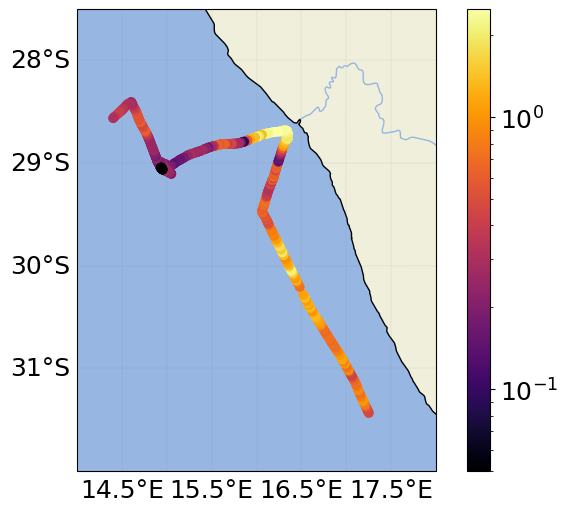

In [286]:
fig, ax = plt.subplots(figsize=(8,6), subplot_kw=dict(projection=crs.PlateCarree()))
ax.coastlines(resolution='10m')
gl = ax.gridlines(color='grey', linestyle='--', lw=0.1, draw_labels=True)

# robinson = crs.Robinson().proj4_init
# horizon_gdf.plot(ax=ax,c='grey')
horizon_gdf.loc[atime:btime].plot(ax=ax,column='cp522.3',legend=True,norm=colors.LogNorm(vmin=0.05, vmax=2.5),cmap='inferno')

# horizon_gdf.loc['2022-05-06 16:30':'2022-05-06 17:30'].plot(ax=ax,c='k') #A
# horizon_gdf.loc['2022-05-07 11':'2022-05-07 13'].plot(ax=ax,c='k') #B 
horizon_gdf.loc['2022-05-08 13:40':'2022-05-08 14:50'].plot(ax=ax,c='k') #C


# ax.set_title('Peak DoLP by Detector')

gl.top_labels = False
gl.right_labels = False

ax.set_ylim(-32,-27.5)
ax.set_xlim(14,18)

ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.LAND)

# fig.tight_layout()

# plt.savefig('figs/cp_map_horizon_paper.png',dpi=300,transparent=True)

plt.show()

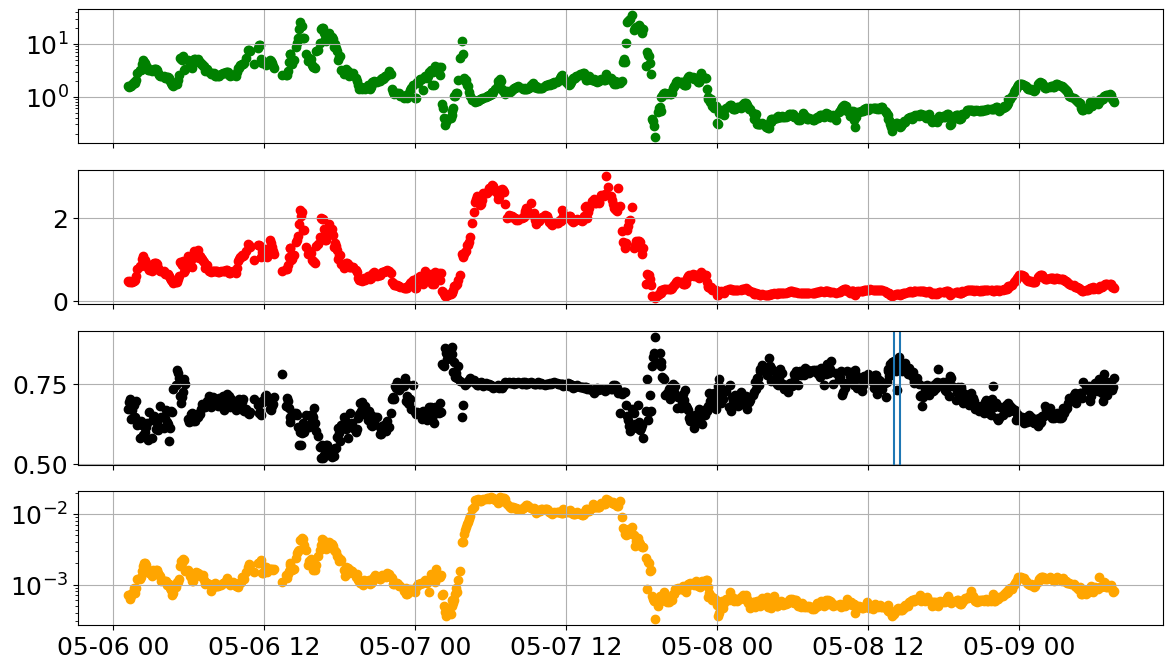

In [298]:
fig, ax = plt.subplots(4,1,figsize=(14,4*2))

ax[0].scatter(horizon_gdf.loc[atime:btime].index, horizon_gdf.loc[atime:btime].Chl_lineheight,c='g')
# ax[0].set_yticks([])
ax[0].set_xticklabels([])
ax[0].set_yscale('log')
ax[0].grid()

ax[1].scatter(horizon_gdf.loc[atime:btime].index, horizon_gdf.loc[atime:btime]['cp522.3'],c='r')
ax[1].set_xticklabels([])
ax[1].grid()

ax[2].scatter(horizon_gdf.loc[atime:btime].index, horizon_gdf.loc[atime:btime].dolp11,c='k')
ax[2].set_xticklabels([])
ax[2].grid()

ax[3].scatter(horizon_gdf.loc[atime:btime].index, horizon_gdf.loc[atime:btime].ssdvsf11,c='orange')
ax[3].set_yscale('log')
ax[3].grid()

ax[2].axvline(pd.to_datetime('2022-05-08 14'))
ax[2].axvline(pd.to_datetime('2022-05-08 14:30'))

# plt.savefig('figs/flow_through_data_horizon.png',dpi=300,transparent=True)

plt.show()

# fig, ax = plt.subplots(figsize=(14,4))

# ax.grid()
# ax.set_yscale('log')
# ax3.set_yscale('log')
# # ax3.set_ylim(0,2)

In [70]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

739
2022-05-08 13:52:49.999999958
0.062221815919887805
LREF:  
765.5
649.5
nonnear_fwd_ratio: 
0.15
0.15
beamc min and max: 
0.0027655779130084488 0.21362138486158525


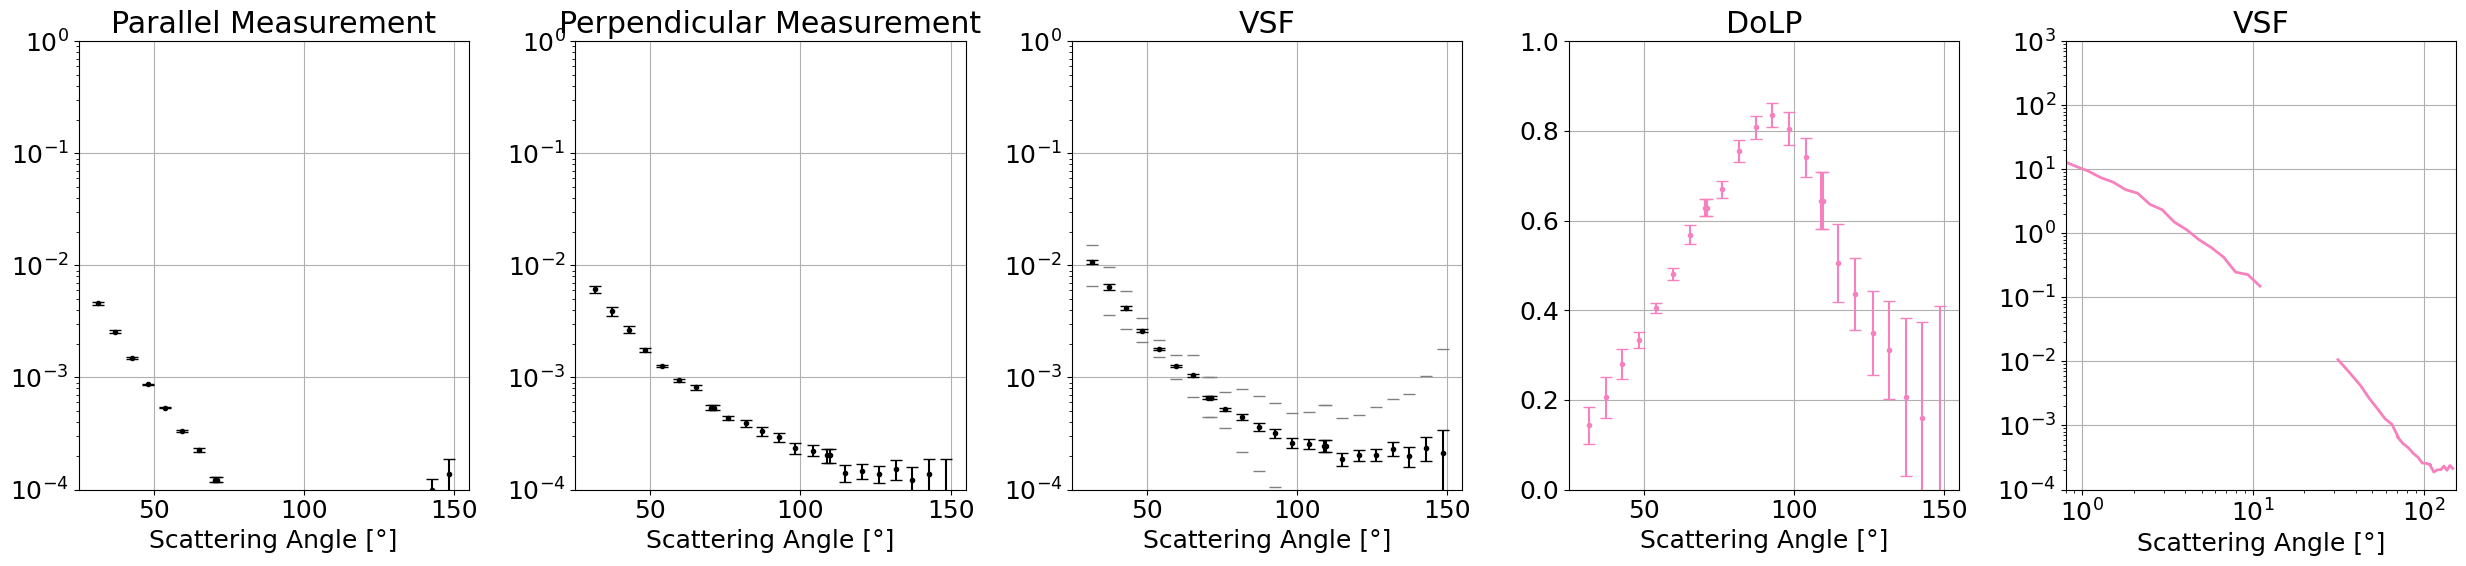

In [83]:
count = 0
mie_count = 0
koestner_idx = 0

ratio_30_150 = []
ratio_meas_mie_150 = []
size_list = []

beamc_list_ms = []
ring32_list_ms = []
det1_list_ms = []
det12_list_ms = []

c = CB_color_cycle[3]

for idx, sid in enumerate(processed.sample_id.unique()):
    samp_df = processed[processed.sample_id == sid]
    # print(samp_df.beamc)

    # if len(samp_df)==0:
    #     print(sid)
    #     continue
    # if ((samp_df.beamc > 25).any() | (samp_df.beamc < 0.1).any()):
    #     mie_count +=1
    #     count +=1
    #     continue
    # if not pd.to_datetime('2022-05-06 16:30') < samp_df.index[0] < pd.to_datetime('2022-05-06 17:30'): #A
    #     count+=1
    #     continue
    # if idx != 265:
    #     count+=1
    #     continue

    # if not pd.to_datetime('2022-05-07 11') < samp_df.index[0] < pd.to_datetime('2022-05-07 13'): #B
    #     count+=1
    #     continue
    # if idx != 462:
    #     count+=1
    #     continue
    
    if not pd.to_datetime('2022-05-08 13:40') < samp_df.index[0] < pd.to_datetime('2022-05-08 14:50'): #C
        count+=1
        continue
    if idx != 739:
        count+=1
        continue
        
    print(idx)
    fig, ax = plt.subplots(1,5, figsize=(25,6))
    print(samp_df.datetime.iloc[0])
    # 
    print(np.median(samp_df.beamc))
    print('LREF:  ')
    print(samp_df['LREF'][samp_df.polarizationAngle==90].median())
    print(samp_df['LREF'][samp_df.polarizationAngle==0].median())

    print('nonnear_fwd_ratio: ')
    print(samp_df[samp_df.polarizationAngle==0]['nonnear_fwd_ratio'].median())
    print(samp_df[samp_df.polarizationAngle==90]['nonnear_fwd_ratio'].median())

    print('beamc min and max: ')
    print(np.nanmin(samp_df.beamc), np.nanmax(samp_df.beamc))

    beamc_median = np.median(samp_df[samp_df.polarizationAngle==0].beamc)
    # I'm just doing it this crazy way so I don't have to change all the code
    beamc_median = 1
    phase_fcn_beamc = 1# np.median(samp_df[samp_df.polarizationAngle==0].beamc) 

    cscatFwd = np.vstack(samp_df[samp_df.polarizationAngle==0].cscatFwd)

    scatFwd = np.vstack(samp_df[samp_df.polarizationAngle==0].scatFwd_tofilter)

    cscatFwd[scatFwd < 100] = np.nan
    
    tau = np.vstack(samp_df[samp_df.polarizationAngle==0].tau)
    zscatFwd = np.median(np.vstack(samp_df[samp_df.polarizationAngle==0].zscatFwd_scaled),axis=0)
    vsf_ssd = (np.nanmedian(np.vstack(samp_df[samp_df.polarizationAngle==0].cscatSsdUncal),axis=0)+np.nanmedian(np.vstack(samp_df[samp_df.polarizationAngle==90].cscatSsdUncal),axis=0))

    vsf_fwd = np.array(cscatFwd_monte_carlo[count*2]).reshape(-1,36).T

    # ax[4].plot(angles_fwd, np.array(cscatFwd_monte_carlo[count*2]).reshape(-1,36).T/phase_fcn_beamc,c='k')
    ax[4].plot(angles_fwd, np.nanmedian(np.array(cscatFwd_monte_carlo[count*2+1]).reshape(-1,36),axis=0)/phase_fcn_beamc,c=c,lw=2)

    pol0 = np.array(monte_carlo_results_0[count])
    pol90 = np.array(monte_carlo_results_90[count])
    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1)) / 5

    
    med90 = np.nanmedian(pol90,axis=(0,1))
    std90 = np.nanstd(pol90,axis=(0,1)) / 5

    med90[med90 < 0.00001] = np.nan
    med0[med0 < 0.00001] = np.nan

    ax[0].errorbar(angles_ssd,med90/phase_fcn_beamc, std90/phase_fcn_beamc,c='k',capsize=4,fmt='.')
    ax[1].errorbar(angles_ssd,med0/phase_fcn_beamc, std0/phase_fcn_beamc,c='k',capsize=4,fmt='.')

    s11_full = unumpy.uarray(med0, std0) + unumpy.uarray(med90, std90)
    s12_full = unumpy.uarray(med0, std0) - unumpy.uarray(med90, std90)

    ratio = unumpy.uarray(med90, std90)/unumpy.uarray(med0, std0)
    dolp = -1*((ratio-1) / (ratio+1))

    min90 = np.nanmin(pol90,axis=(0,1))
    max90 = np.nanmax(pol90,axis=(0,1))
    min0  = np.nanmin(pol0,axis=(0,1))
    max0  = np.nanmax(pol0,axis=(0,1))

    min90[min90 < 0] =0
    min0[min0 < 0] =0
    

    s11_full = unumpy.uarray(med0, std0) + unumpy.uarray(med90, std90)
    s11_min = min90 + min0
    s11_max = max90 + max0
    
    s12_full = unumpy.uarray(med0, std0) - unumpy.uarray(med90, std90)
    # TODO make it so values below 0 are set to 0, we can't actually have a negative scattering value
    s12_min = min0 - max90
    s12_max = max0 - min90

    s12_min[s12_min < 0] =0
    s12_max[s12_max < 0] =0

    ratio_max = max90/min0
    dolp_max = -1*((ratio_max-1) / (ratio_max+1))

    ratio_min = min90/max0
    dolp_min = -1*((ratio_min-1) / (ratio_min+1))

    dolp_min[np.isnan(dolp_min)] = 1
    dolp_max[np.isnan(dolp_max)] = -1


    beamc_list_ms.append(phase_fcn_beamc)
    ring32_list_ms.append(vsf_fwd[-1])
    det1_list_ms.append(s11_full[0])
    det12_list_ms.append(s11_full[12])

    
    # ax[0].errorbar(angles_ssd, med90/phase_fcn_beamc, np.array([med90/phase_fcn_beamc-min90/phase_fcn_beamc, max90/phase_fcn_beamc-med90/phase_fcn_beamc]),color='grey',alpha=0.5,fmt='none',capsize=4, linewidth=0)
    
    # ax[1].errorbar(angles_ssd, med0/phase_fcn_beamc, np.array([med0/phase_fcn_beamc-min0/phase_fcn_beamc, max0/phase_fcn_beamc-med0/phase_fcn_beamc]),color='grey',alpha=0.5,fmt='none',capsize=4, linewidth=0)
    
    ax[2].errorbar(angles_ssd,unumpy.nominal_values(s11_full)/phase_fcn_beamc, np.array([unumpy.nominal_values(s11_full)/phase_fcn_beamc - s11_min/phase_fcn_beamc, s11_max/phase_fcn_beamc - unumpy.nominal_values(s11_full)/phase_fcn_beamc]),color='grey',fmt='none',capsize=4, linewidth=0)


    
    # ax[3].errorbar(angles_ssd, unumpy.nominal_values(dolp), abs(np.array([unumpy.nominal_values(dolp)-dolp_min, dolp_max-unumpy.nominal_values(dolp)])),color='grey',fmt='none',capsize=4, linewidth=0)

    ax[2].errorbar(angles_ssd,unumpy.nominal_values(s11_full)/phase_fcn_beamc, unumpy.std_devs(s11_full)/phase_fcn_beamc,c='k',capsize=4,fmt='.')


    # ax[4].errorbar(angles_ssd,unumpy.nominal_values(s11_full)/phase_fcn_beamc, unumpy.std_devs(s11_full)/phase_fcn_beamc,c='k',capsize=4,fmt='.')
    ax[4].plot(angles_ssd,unumpy.nominal_values(s11_full)/phase_fcn_beamc, c=c,lw=2)

    ax[3].errorbar(angles_ssd,unumpy.nominal_values(dolp), unumpy.std_devs(dolp),c=c,capsize=4,fmt='.')


    ax[0].set_yscale('log')
    ax[1].set_yscale('log')
    ax[2].set_yscale('log')
    ax[4].set_yscale('log')
    ax[0].set_ylim(0.0001,1)
    ax[1].set_ylim(0.0001,1)
    ax[2].set_ylim(0.0001,1)
    ax[3].set_ylim(0,1)
    ax[4].set_ylim(0.0001,1000)
    ax[4].set_xlim(.8,155)
    ax[0].set_xlim(25,155)
    ax[1].set_xlim(25,155)
    ax[2].set_xlim(25,155)
    ax[3].set_xlim(25,155)
    ax[4].set_xscale('log')

    ax[0].set_title('Parallel Measurement')
    ax[1].set_title('Perpendicular Measurement')
    ax[2].set_title('VSF')
    ax[3].set_title('DoLP')
    ax[4].set_title('VSF')

    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    ax[3].grid()
    ax[4].grid()

    ax[0].set_xlabel('Scattering Angle [°]')
    ax[1].set_xlabel('Scattering Angle [°]')
    ax[2].set_xlabel('Scattering Angle [°]')
    ax[3].set_xlabel('Scattering Angle [°]')
    ax[4].set_xlabel('Scattering Angle [°]')

    count +=1
    mie_count +=1
    fig.tight_layout()
    # plt.savefig('figs/'+str(bead_diams[idx])+'_'+str(idx)+'_bead_comps_080526.png',dpi=300)
    plt.savefig('figs/horizon_exampleCC.png',dpi=300,transparent=True)
    plt.show()